In [49]:
import numpy as np
import yaml

from copy import deepcopy
import numpy as np

from witch.fitter import load_config
from witch.cfg_loader import load_cfg

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
#Load in the data and models.
#TODO: right now this does some busy work loading the data and e.g. computing the noise map
#that it probably doesn't need to do if all you want to do is look at the model. Still it
#doesn't take very long and it's useful in other circumstances so I'm going to leave it in for the timebeing.

path = "/home/elebar/joint/WITCH/configs/xray_test/MOO1142_Xray.yaml"
cfg = load_config({}, path)
datasets, outdir, dset_names, metamodel = load_cfg(cfg)


Outputs can be found in /mnt/welch/USERS/elebar/Reductions/X_MOO1142/model_ns/first_try/r_1-beta-amp-P0-r_s-beta
Map scale:  2.7008111


0.9999995


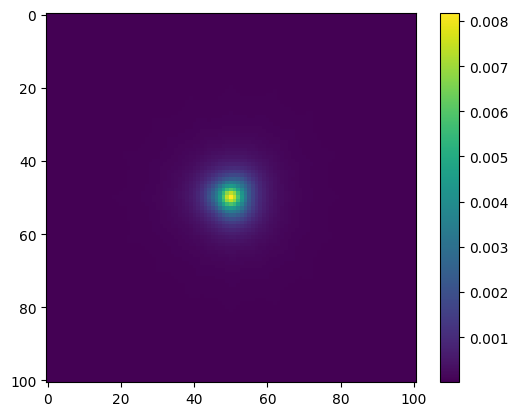

In [56]:
plt.imshow(metamodel.datasets[0].metadata[0].beam_map)
plt.colorbar()
print(np.sum(metamodel.datasets[0].metadata[0].beam_map))

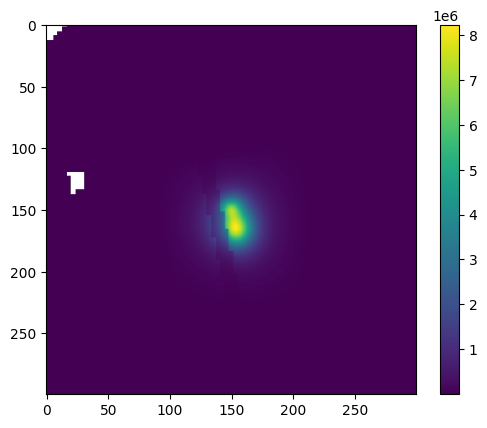

In [52]:
#To plot the full model on a given dataset, we use
#metamodel.model_grid(i), where i is the dataset of interest
#Plotting multiple datasets at the same time is in general non-sensical
#i.e. plotting x-ray and M2 simultaneously. However it can sometimes be 
#well defined (i.e. ACT+M2). In that case, you have to manually
# 1) get the maps in the same units 
# 2) get the maps in the same pixelation, probably by interpolation
#This is a pretty niche application so no example is given here
plt.imshow(metamodel.model_grid(0))
plt.colorbar()


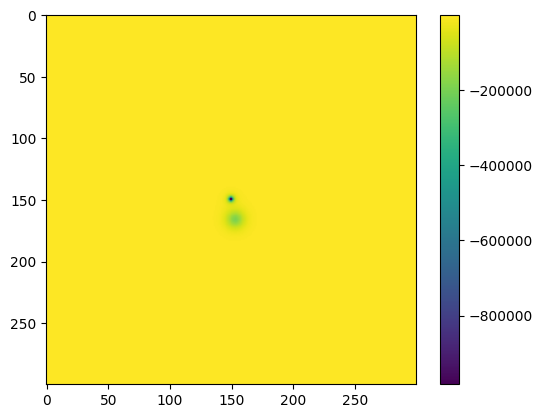

In [53]:
#If you want to only look at one component of the model, you can do the following:

plt.imshow(metamodel.models[0].model*metamodel.datasets[0].metadata[0].prefactor)
plt.colorbar()

In [54]:
#If you want to update parameters, do something like this

pars = np.array(deepcopy(metamodel.parameters))
pars[-1] = 1e-3

metamodel.update(pars, metamodel.errors, metamodel.chisq)

plt.imshow(metamodel.model_grid(0))
plt.colorbar()

AttributeError: 'MetaModel' object has no attribute 'errors'